# **Análisis Experiencia de cliente**

Objetivos analista d'experiència del client:

- Quina és la puntuació mitjana donada pels usuaris als allotjaments turístics?
- Quin percentatge d'allotjaments tenen una avaluació general més gran de 80 a cada ciutat?

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [148]:
df = pd.read_csv("../../Data/clean_data_09-03-2026.csv", parse_dates=['insert_date'] )

df.head()

,apartment_id,room_type,price,has_availability,availability_30,availability_60,availability_90,availability_365,review_scores_rating,first_review_date,last_review_date,number_of_reviews,reviews_per_month,city,insert_date,reviews 80+
0,11964,Private room,400.0,True,7,20,40,130,97.0,2010-01-02,2017-09-05,78,0.76,Malaga,2018-07-31,True
1,21853,Private room,170.0,True,0,0,0,162,92.0,2014-10-10,2018-07-15,33,0.52,Madrid,2020-01-10,True
2,32347,Entire home/apt,990.0,True,26,31,31,270,98.0,2011-01-05,2019-07-22,148,1.44,Sevilla,2019-07-29,True
3,35379,Private room,400.0,True,9,23,49,300,94.0,2012-03-13,2020-01-04,292,3.10,Barcelona,2020-01-10,True
4,35801,Private room,900.0,True,0,19,49,312,97.0,2011-07-08,2018-08-08,36,0.39,Girona,2019-02-19,True


La columna *reviews_per_month* está recalculada en base a la primera review del alojamiento (*first_review_date*) y la fecha de extracción del registro (*insert_date*). De esta manera, obtenemos los meses reales que existen en los que se han posteado reseñas. Dividimos total de reviews (*number_of_reviews*) con esos meses y obtenemos esta columna recalculada correctamente.

## **Reviews**

## Análisis descriptivos simples

Puntuación media, mediana y moda de reviews

In [149]:
avg_rating = df["review_scores_rating"].mean()

print("Puntuación media:", round(avg_rating, 2))

print("Puntuación mediana:", df['review_scores_rating'].median())
print("Puntuación modal:", df['review_scores_rating'].mode()[0])


Puntuación media: 91.99
Puntuación mediana: 94.0
Puntuación modal: 100.0


Para los algoritmos de recomendación de la plataforma, un alojamiento que baja de 4.5 suele ser penalizado y aparece mucho más abajo en las búsquedas. 

Por eso, en análisis de negocio, el 4.5 es la "frontera de supervivencia".

En nuestra escala, eso equivaldría a un 9/10.

Histograma distribución de reviews según precio

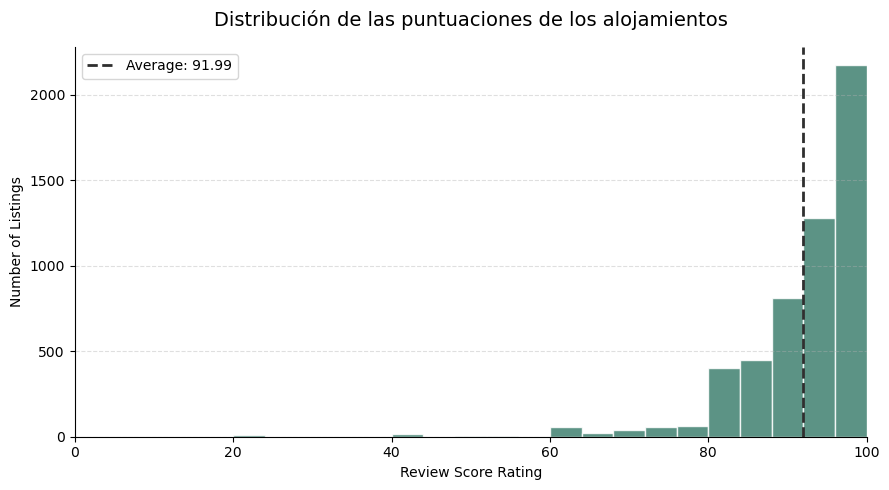

In [150]:
ratings = df["review_scores_rating"].dropna()

# media
avg_rating = ratings.mean()

plt.figure(figsize=(9,5))

# histograma
plt.hist(
    ratings,
    bins=20,
    color="#3f8070",
    edgecolor="white",
    alpha=0.85
)

# línea de media
plt.axvline(
    avg_rating,
    linestyle="--",
    linewidth=2,
    color="#2f2f2f",
    label=f"Average: {avg_rating:.2f}"
)

# límites eje X
plt.xlim(0,100)

# estilo limpio
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.title("Distribución de las puntuaciones de los alojamientos", fontsize=14, pad=15)
plt.xlabel("Review Score Rating")
plt.ylabel("Number of Listings")

plt.legend()

for spine in ["top","right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

Como es una distribución asimétrica, mejor usar la mediana que la media, ya que nos da una aproximación mejor para describir el conjunto.

Puntuación media por ciudad

In [151]:
df.groupby('city')[['review_scores_rating']].mean().sort_values(by='review_scores_rating',ascending=False).round(2)

,review_scores_rating
city,
Sevilla,93.78
Menorca,93.37
Mallorca,93.36
Madrid,92.76
Valencia,92.44
Malaga,92.13
Girona,91.06
Barcelona,90.71


Puntuación mediana por ciudad

In [152]:
df.groupby('city')[['review_scores_rating']].median().sort_values(by='review_scores_rating',ascending=False)

,review_scores_rating
city,
Mallorca,96.0
Madrid,95.0
Menorca,95.0
Sevilla,95.0
Girona,94.0
Valencia,94.0
Barcelona,93.0
Malaga,93.0


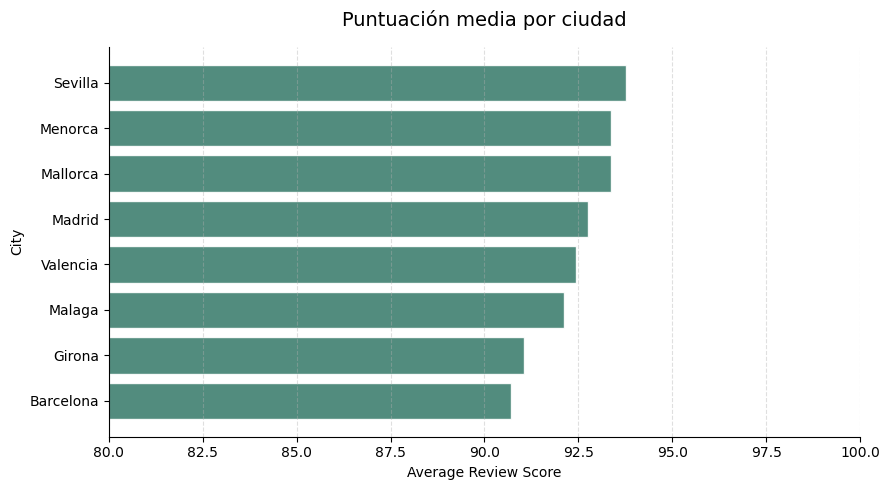

In [153]:
import pandas as pd
import matplotlib.pyplot as plt



# cálculo
avg_rating_city = (
    df.groupby("city")["review_scores_rating"]
      .mean()
      .sort_values(ascending=False)
      .round(2)
      .to_frame(name="avg_rating")
)

plt.figure(figsize=(9,5))

plt.barh(
    avg_rating_city.index,
    avg_rating_city["avg_rating"],
    color="#3f8070",
    edgecolor="white",
    alpha=0.9
)

plt.gca().invert_yaxis()

plt.title("Puntuación media por ciudad", fontsize=14, pad=15)
plt.xlabel("Average Review Score")
plt.ylabel("City")

plt.grid(axis="x", linestyle="--", alpha=0.4)

for spine in ["top","right"]:
    plt.gca().spines[spine].set_visible(False)

plt.xlim(80,100)

plt.tight_layout()
plt.show()

Ciudades con más reviews

<Axes: xlabel='city'>

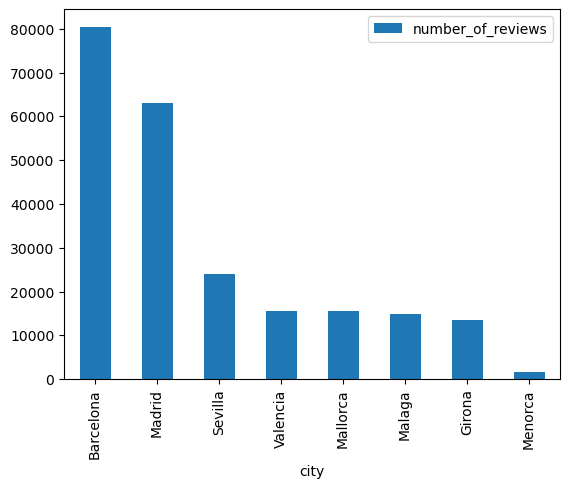

In [154]:
df.groupby('city')[['number_of_reviews']].sum().sort_values(by='number_of_reviews',ascending=False).plot.bar()

Media de numero de reseñas por alojamiento

In [155]:
#Average del total de reviews
avg_reviews_total = df["number_of_reviews"].mean()

print(f"Avg number of reviews per listing: {avg_reviews_total:.2f}")

Avg number of reviews per listing: 34.51


## KPI

In [156]:
# Filtro para el cálculo. Filtramos SOLO los 2 valores infinitos para poder calcular reviews_per_month

filas_infinitas = df[np.isinf(df['reviews_per_month'])]


In [157]:
# KPI 1 — Average rating
avg_rating = df["review_scores_rating"].mean()

# KPI 2 — Average reviews per month
avg_reviews_month = df["reviews_per_month"].drop(filas_infinitas.index).mean()

print("KPI RESULTS")
print("---------------------")
print(f"Avg rating (all scores): {avg_rating:.2f}")
print(f"Avg reviews per month: {avg_reviews_month:.2f}")

KPI RESULTS
---------------------
Avg rating (all scores): 91.99
Avg reviews per month: 1.47


## Outliers

Vamos a ver a quién pertenecen los outliers. (Estiran la media hacia la baja)

Los que tienen outliers con puntuaciones más bajas coinciden con las 4 ciudades con más alojamientos del dataset.

<Axes: xlabel='city'>

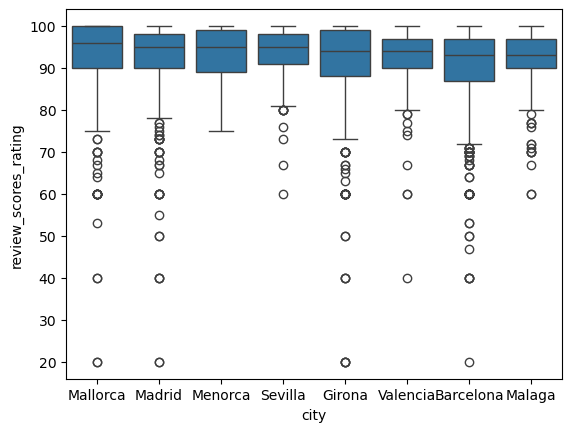

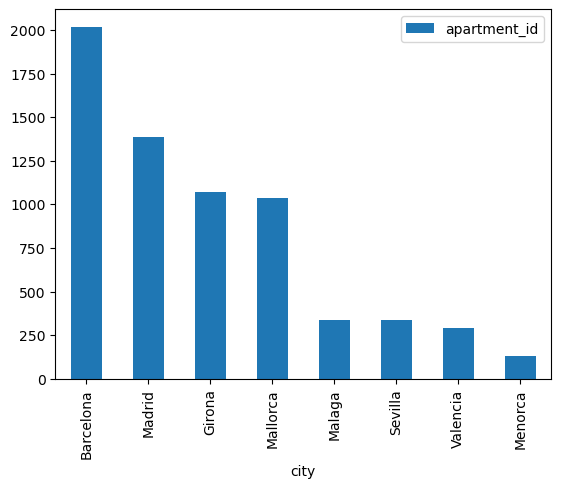

In [158]:
orden_ciudades = df.groupby('city')['review_scores_rating'].median().sort_values(ascending=False).index

sns.boxplot(data=df, x='city', y='review_scores_rating', order = orden_ciudades)

df.groupby('city')[['apartment_id']].count().sort_values(by='apartment_id',ascending=False).plot.bar()

Han salido 76 apartamentos que tienen numero de reseñas, pero valores nulos en Reviews (Error?)

En cambio, hay 1251 apartamentos que no tienen reviews todavía (Son nuevos? / No tienen reseña simplemente?)

In [159]:
# Filtramos los apartamentos que tienen alguna reseña, pero que no tienen nota global
anomalias = df[(df['number_of_reviews'] > 0) & (df['review_scores_rating'].isna())]

print(f"Número de casos raros encontrados: {len(anomalias)}")
# anomalias.sort_values(by="number_of_reviews", ascending=False) No tienen muchas reviews

Número de casos raros encontrados: 74


In [160]:
sin_review = df[(df['number_of_reviews'] == 0) & (df['review_scores_rating'].isna())]
sin_review
print(f"Número de apartamentos sin review encontrados: {len(sin_review)}")

Número de apartamentos sin review encontrados: 1161


## Análisis bivariados

Quin percentatge d'allotjaments tenen una avaluació general més gran de 80 a cada ciutat?

In [161]:
# Alojamientos con calificación superior a 8, por ciudad.
rating_superior_8 = df.loc[df['review_scores_rating'] >= 8].groupby('city')[['apartment_id']].count()

# El total de alojamientos por ciudad
total_por_ciudad = df.groupby('city')[['apartment_id']].count()

# Porcentaje de alojamientos con una calificación mayor a 8, según ciudad.
alojamientos_top_ciudad = (rating_superior_8 / total_por_ciudad )* 100

alojamientos_top_ciudad.sort_values('apartment_id', ascending=False)


,apartment_id
city,
Valencia,93.877551
Sevilla,92.330383
Malaga,91.445428
Madrid,85.425685
Menorca,83.582090
Barcelona,83.234127
Mallorca,73.648649
Girona,69.467787


<Axes: xlabel='city'>

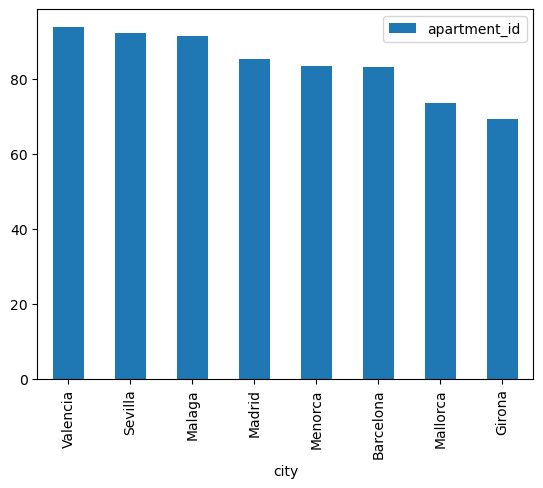

In [173]:
alojamientos_top_ciudad.sort_values('apartment_id', ascending=False).plot.bar()

Curva de Distribución Acumulada

¿Qué porcentaje de mis alojamientos tienen una nota igual o superior a 80?

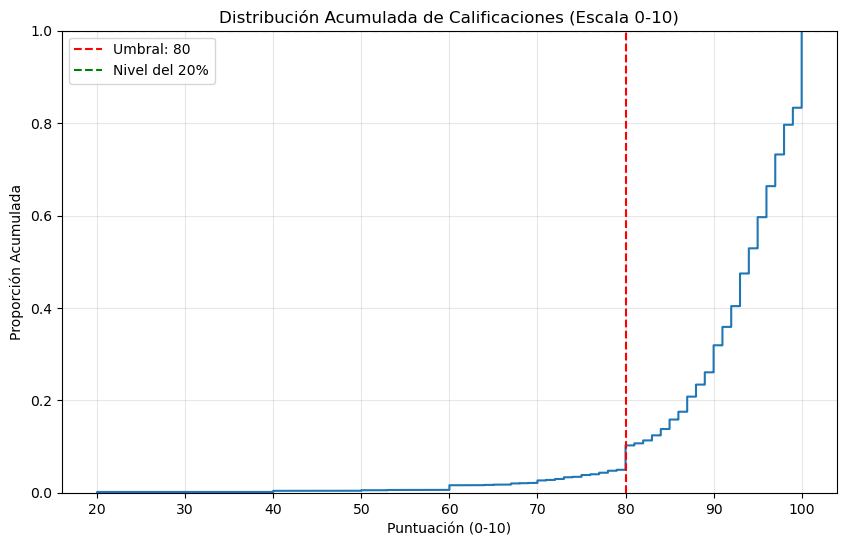

In [162]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.ecdfplot(data=df, x='review_scores_rating')

# 3. Líneas de referencia para una lectura rápida
# Por ejemplo: queremos ver qué porcentaje está por encima de un 80
plt.axvline(80, color='red', linestyle='--', label='Umbral: 80')
plt.axhline(1, color='green', linestyle='--', label='Nivel del 20%')

plt.title('Distribución Acumulada de Calificaciones (Escala 0-10)')
plt.xlabel('Puntuación (0-10)')
plt.ylabel('Proporción Acumulada')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Por encima de un rating de 8, el 95% de los alojamientos.

Por encima de un rating de 9, el 74% de los alojamientos.

In [163]:
# % alojamientos por encima del rating 8
total_alojamientos_con_review= df.dropna(subset=['review_scores_rating']) # Cuidado con los nulos, hay que descartar para que porcentaje sea correcto.

total_alojamientos_con_review = total_alojamientos_con_review.shape[0] # Sacamos nº total de alojamientos con review

rating_above_8 = df.loc[df['review_scores_rating'] >= 80][['apartment_id']].count() 
rating_above_9 = df.loc[df['review_scores_rating'] >= 90][['apartment_id']].count() 
per_above_8 = rating_above_8 / total_alojamientos_con_review
per_above_9 = rating_above_9 / total_alojamientos_con_review
print(per_above_8)
print(per_above_9)

apartment_id    0.950372
dtype: float64
apartment_id    0.739405
dtype: float64


## Tarjetas

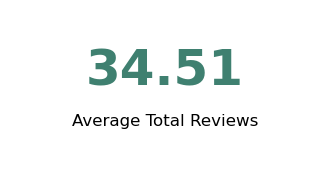

In [164]:
plt.figure(figsize=(4,2))

plt.text(
    0.5, 0.6,
    f"{avg_reviews_total:.2f}",
    ha="center",
    va="center",
    fontsize=36,
    color="#3f8070",
    fontweight="bold"
)

plt.text(
    0.5, 0.25,
    "Average Total Reviews",
    ha="center",
    fontsize=12
)

plt.axis("off")
plt.show()

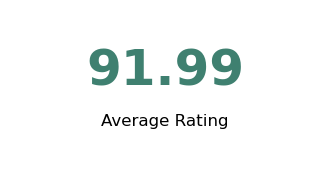

In [165]:
plt.figure(figsize=(4,2))

plt.text(
    0.5, 0.6,
    f"{avg_rating:.2f}",
    ha="center",
    va="center",
    fontsize=36,
    color="#3f8070",
    fontweight="bold"
)

plt.text(
    0.5, 0.25,
    "Average Rating",
    ha="center",
    fontsize=12
)

plt.axis("off")
plt.show()

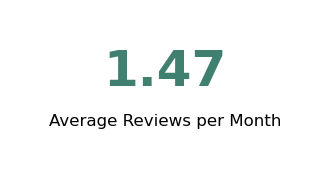

In [166]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4,2))

plt.text(
    0.5, 0.6,
    f"{avg_reviews_month:.2f}",
    ha="center",
    va="center",
    fontsize=36,
    color="#3f8070",
    fontweight="bold"
)

plt.text(
    0.5, 0.25,
    "Average Reviews per Month",
    ha="center",
    fontsize=12
)

plt.axis("off")
plt.show()